# Execises

The following data set is from https://www.kaggle.com/code/sonialikhan/body-fat-prediction-dataset-2024 on body fat density

The definition and measurement of density is described in the documentation

In the following we are going to use some Linear Normal Models to describe the data based on the various parameters given in the dataset


## Data loading

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

from numpy.ma.core import ones

warnings.filterwarnings('ignore')
data = pd.read_csv ('bodyfat.csv')
df = pd.DataFrame (data)
df

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


## Exercise 1
Before starting to model data it is a good idea to get an overview of the data

Make a plot of density by weight. In this first plot do not keep other parameters fixed




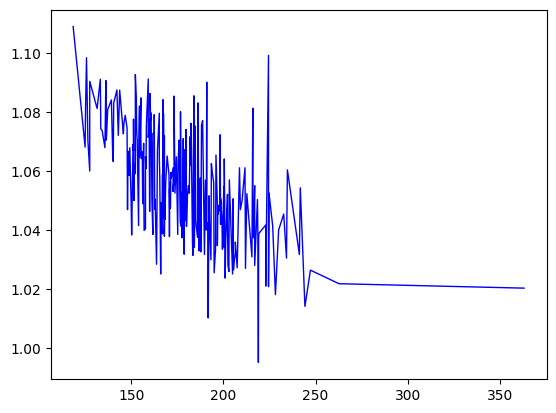

In [132]:
import numpy as np
import matplotlib.pyplot as plt

x = df['Weight']
y = df['Density']

idx = np.argsort(x)
x = x[idx]
y = y[idx]

plt.plot(x, y, linewidth=1, color='blue')
plt.show()

### Exercise 2
From the loaded data make two nested hypotheses H_F (full) and H_R(restricted) and test by F-test and verify that the restricted hypothesis should be rejected in favor of the full hypothesis

The  models are designed as
\begin{align*}
D_R=
\begin{bmatrix}
1\\
1\\
\dots \\
1
\end{bmatrix}
D_F=
\begin{bmatrix}
1& weight_1\\
1& weight_2\\
\vdots & \vdots \\
1 & weight_n\\
\end{bmatrix}
\end{align*}

In [120]:
from scipy.stats import f
D_F = np.column_stack((np.ones(len(df)), df['Weight']))
D_R = np.ones((len(df), 1))
Y = df.drop(columns=['Weight']).to_numpy()

p_F = D_F.shape[1]
p_R = D_R.shape[1]
n = len(df)

Beta_hat_F = np.linalg.inv((D_F.T@D_F))@D_F.T@Y

Beta_hat_R = np.linalg.inv((D_R.T@D_R))@D_R.T@Y

SSE_F = np.linalg.norm(Y-D_F@Beta_hat_F)**2

SSE_R = np.linalg.norm(Y-D_R@Beta_hat_R)**2

Sigma2_hat_F = 1/(n - p_F)*SSE_F

Sigma2_hat_R = 1/(n - p_R)*SSE_R


T = ((SSE_R-SSE_F)/(p_F-p_R))/(SSE_F / (n - p_F))
    
print(T)



alpha = 0.05

F_crit = f.ppf(1-alpha, p_F-p_R, n-p_F)
print(F_crit)

if T >= F_crit:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")


233.886075181298
3.878923921688504
Reject the null hypothesis


In [123]:
from scipy.stats import f
D_F = np.column_stack((np.ones(len(df)), df['Weight']))
D_R = np.ones((len(df), 1))
Y = df['Density'].to_numpy()

p_F = D_F.shape[1]
p_R = D_R.shape[1]
n = len(df)

Beta_hat_F = np.linalg.inv((D_F.T@D_F))@D_F.T@Y

print(Beta_hat_F)

Beta_hat_R = np.linalg.inv((D_R.T@D_R))@D_R.T@Y

SSE_F = np.linalg.norm(Y-D_F@Beta_hat_F)**2

SSE_R = np.linalg.norm(Y-D_R@Beta_hat_R)**2

Sigma2_hat_F = 1/(n - p_F)*SSE_F

Sigma2_hat_R = 1/(n - p_R)*SSE_R


T = ((SSE_R-SSE_F)/(p_F-p_R))/(SSE_F / (n - p_F))
    
print(T)



alpha = 0.05

F_crit = f.ppf(1-alpha, p_F-p_R, n-p_F)
print(F_crit)

if T >= F_crit:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

[ 1.12440505e+00 -3.84694545e-04]
136.3447302927681
3.878923921688504
Reject the null hypothesis


## Exercise 3
Plot the scattered data and the estimated line in the same plot


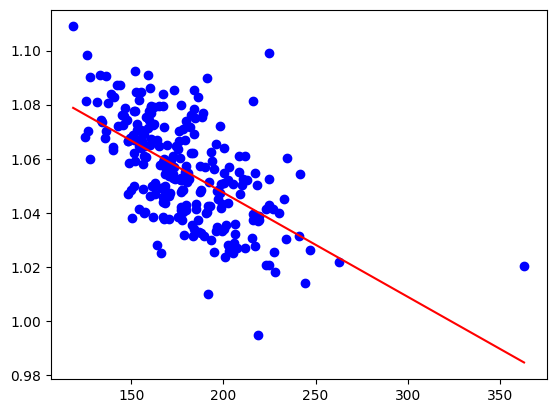

In [127]:
x1 = df['Weight']
y1 = df['Density']
plt.scatter(x1, y1, color='blue')

x2 = np.linspace(min(df['Weight']), max(df['Weight']), 100)
y2 = Beta_hat_F[0] + Beta_hat_F[1]*x2
plt.plot(x2, y2, color='red')

plt.show()

## Exercise 4
The restricted model should be rejected and so we move on with a new test
\begin{align*}
D_R=
\begin{bmatrix}
1& weight_1\\
1& weight_2\\
\vdots & \vdots\\
1 & weight_n\\
\end{bmatrix}
D_F=
\begin{bmatrix}
1& weight_1 & height_1\\
1& weight_2 & height_1\\
\vdots & \vdots &\vdots\\
1 & weight_n & height_n\\
\end{bmatrix}
\end{align*}


## Exercise 5
Try to scatter plot and plot fit in 3D for the model of exercise 3

## Exercise 6
As you can se it is hard to evaluate the result in a 3d-plot. So often it is better to make several 2d-plots.

Try to play around with new models that extend the previous model.

## Exercise 7

Consider the D_F for the model with only a constant and weight

Try to solve the least square problem by using QR decomposition formula instead of using back substitution just use numpy inverse of R insted of back substitution.

Confirm that the result is the same

And confirm that $Q^TQ=I$


## Exercise 8
Calculate the $R^2$ value for the model (1,weight,height) to evaluate the fit of that model

Compare with $F$-test